<a href="https://colab.research.google.com/github/selcukkanun/DSA210-F1-LOGISTICS/blob/main/ML_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Project Objective**
The objective of this project is to investigate which measurable performance characteristics distinguish Formula 1 World Drivers’ Champions from non-champions. Rather than attempting to predict future championships or establish causal relationships, the analysis aims to identify statistical patterns associated with championship-level performance using regression and machine learning techniques.

##Methodology Overview
The analysis proceeds in three main stages. First, we construct a driver-level dataset summarizing career performance using race results, teammate comparisons, and wet-weather outcomes. Second, supervised learning models are employed to identify which performance features best separate champions from non-champions. Finally, unsupervised learning and probabilistic classification methods are used to explore performance archetypes and identify drivers with champion-like statistical profiles.


###Feature Engineering
To capture multiple dimensions of driver performance, four primary features were engineered:

- Teammate Beating Rate: The proportion of races in which a driver finished ahead of their teammate, measuring relative dominance within the same machinery.
- Total Races: A proxy for career longevity and experience.
- Wet-Weather Win Rate: The fraction of wet races won by a driver, capturing performance under difficult driving conditions.
- Wet-Weather Podiums: The total number of podium finishes in wet races, emphasizing consistency rather than rare peak performance.


To reduce noise arising from small sample sizes, the dataset was restricted to drivers with at least five wet-weather races and eight total career races.

In [6]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load preprocessed datasets

# Race-level results including wet-weather information
df_results = pd.read_csv("driver_finishing_positions.csv")

# Driver-level teammate beating statistics
df_beating = pd.read_csv("clean_teammate_beating_rate.csv")

# Construct wet-weather performance metrics
wet_races = df_results[df_results["is_true_wet"] == True]

wet_stats = wet_races.groupby("driverId").agg(
    wet_races_count=("raceId", "count"),
    wet_wins=("positionText", lambda x: (x == "1").sum()),
    wet_podiums=("positionText", lambda x: x.isin(["1", "2", "3"]).sum())
).reset_index()

wet_stats["wet_win_rate"] = wet_stats["wet_wins"] / wet_stats["wet_races_count"]

# Require at least 5 wet races for reliable estimates
wet_stats = wet_stats[wet_stats["wet_races_count"] >= 5]


## Merging Driver-Level Features

The wet-weather statistics are merged with previously computed teammate beating
rates to form a unified driver-level dataset. Drivers without sufficient wet
race data are assigned zero values to ensure numerical stability in machine
learning models.


In [7]:
# Merge datasets and create final ML table

df_ml = pd.merge(df_beating, wet_stats, on="driverId", how="left")
df_ml = df_ml.fillna(0)

# Create champion label
world_champions_list = [
    "Alain Prost", "Ayrton Senna", "Nigel Mansell", "Michael Schumacher",
    "Mika Hakkinen", "Damon Hill", "Jacques Villeneuve", "Fernando Alonso",
    "Kimi Raikkonen", "Jenson Button", "Sebastian Vettel", "Lewis Hamilton",
    "Nico Rosberg", "Max Verstappen", "Mika Häkkinen", "Kimi Räikkönen"
]

df_ml["full_name"] = df_ml["forename"] + " " + df_ml["surname"]
df_ml["is_champion"] = df_ml["full_name"].isin(world_champions_list).astype(int)

# Filter drivers with limited careers
df_ml_filtered = df_ml[df_ml["total_races"] >= 8].copy()

print(f"Drivers remaining after filtering: {len(df_ml_filtered)}")


Drivers remaining after filtering: 85


#Supervised Learning: Random Forest
A Random Forest classifier was trained to distinguish World Champions from non-champions using the engineered performance features. Feature importance analysis revealed that wet-weather podium finishes and teammate beating rate were the most informative variables, while total race count played a comparatively smaller role. This suggests that consistent high-level performance—particularly under challenging conditions—is more characteristic of champions than experience alone.

/tmp/ipython-input-2402268093.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_model.feature_importances_, y=features, palette="viridis")


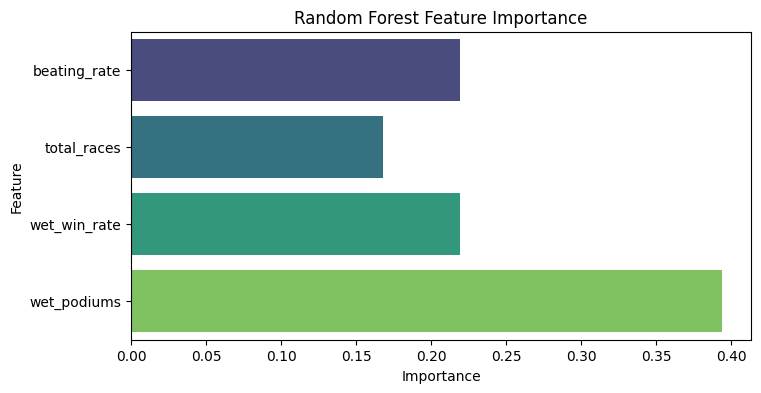

In [8]:
features = ["beating_rate", "total_races", "wet_win_rate", "wet_podiums"]
X = df_ml_filtered[features]
y = df_ml_filtered["is_champion"]

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)
rf_model.fit(X, y)

plt.figure(figsize=(8, 4))
sns.barplot(x=rf_model.feature_importances_, y=features, palette="viridis")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Unsupervised Learning: Clustering Driver Profiles

To explore whether drivers naturally group into performance archetypes, we apply
K-Means clustering to the standardized feature set without using championship
labels. This allows us to examine whether champions occupy distinct regions in
feature space.

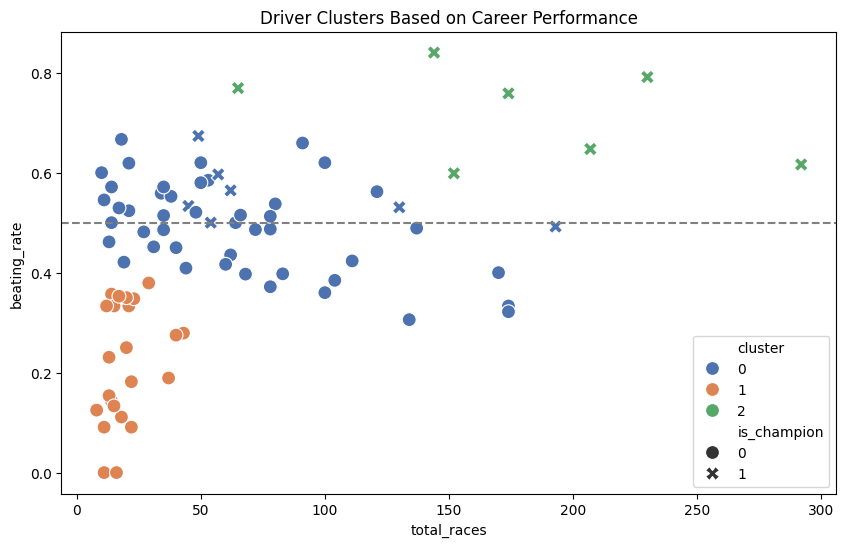

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ml_filtered["cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_ml_filtered,
    x="total_races",
    y="beating_rate",
    hue="cluster",
    style="is_champion",
    palette="deep",
    s=100
)
plt.axhline(0.5, linestyle="--", color="gray")
plt.title("Driver Clusters Based on Career Performance")
plt.show()


## Probabilistic Classification: Champion-Like Profiles

Finally, logistic regression is used to estimate the probability that a driver
belongs to the champion class given their performance profile. These probabilities
are interpreted as measures of similarity to historical champions rather than
predictions of future success.


In [10]:
log_reg = LogisticRegression()
log_reg.fit(X, y)

df_ml_filtered["champ_probability"] = log_reg.predict_proba(X)[:, 1]

outliers = (
    df_ml_filtered[df_ml_filtered["is_champion"] == 0]
    .sort_values("champ_probability", ascending=False)
)

print("Top non-champions with champion-like profiles:")
print(outliers[["full_name", "beating_rate", "wet_win_rate", "champ_probability"]].head(15))


Top non-champions with champion-like profiles:
                 full_name  beating_rate  wet_win_rate  champ_probability
21      Rubens Barrichello      0.305970      0.036364           0.815791
42              Jean Alesi      0.552632      0.000000           0.492197
12            Felipe Massa      0.333333      0.057143           0.434305
115           Sergio Pérez      0.321839      0.074074           0.433179
13         David Coulthard      0.360000      0.024390           0.313686
80        Riccardo Patrese      0.189189      0.000000           0.191292
38   Heinz-Harald Frentzen      0.558824      0.035714           0.146248
1            Nick Heidfeld      0.500000      0.000000           0.137999
56          Gerhard Berger      0.435484      0.000000           0.133036
16             Mark Webber      0.384615      0.000000           0.125838
141           Lando Norris      0.659341      0.000000           0.089063
8            Robert Kubica      0.584906      0.000000           

#**Summary**
Overall, the analysis demonstrates that World Champions are statistically distinguished by sustained dominance over teammates and strong performance in wet-weather conditions. While the methods used do not establish causality or predict future championship outcomes, they provide meaningful insight into the performance profiles commonly associated with championship-level drivers.